<h2>Exercise 07: Heatmap</h2>

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Preprocessing

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df_checker = pd.io.sql.read_sql(
    """
    SELECT
        *
    FROM checker
    WHERE "uid" LIKE "user_%"
    """,
    conn,
    parse_dates=["timestamp"]
)

df_checker

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [4]:
total_commits = df_checker["uid"].value_counts().reset_index(name="commits")
total_commits

,uid,commits
0,user_4,368
1,user_14,259
2,user_2,235
3,user_25,233
4,user_19,176
5,user_26,173
6,user_20,165
7,user_31,144
8,user_10,137
9,user_3,134


In [5]:
commit_day = df_checker.copy()
commit_day["day"] = commit_day["timestamp"].dt.weekday
commit_day["hour"] = commit_day["timestamp"].dt.hour
commit_day.drop(["index", "status", "success", "numTrials"], inplace=True, axis="columns")
commit_day

,timestamp,labname,uid,day,hour
0,2020-04-17 05:19:02.744528,project1,user_4,4,5
1,2020-04-17 05:22:35.249331,project1,user_4,4,5
2,2020-04-17 05:22:45.549397,project1,user_4,4,5
3,2020-04-17 05:34:14.691200,project1,user_4,4,5
4,2020-04-17 05:34:24.422370,project1,user_4,4,5
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,laba06s,user_1,3,20
3203,2020-05-21 20:22:41.785725,laba06s,user_1,3,20
3204,2020-05-21 20:22:41.877806,laba06s,user_1,3,20
3205,2020-05-21 20:37:00.129678,laba06s,user_1,3,20


In [6]:
stats_commit_day = commit_day.groupby(["uid","day", "hour"]).size()


uids = commit_day['uid'].unique()
days = range(7)          # если дни — это конкретные даты из данных
hours = range(24)                          # все часы от 0 до 23

# Создаём мультииндекс из всех комбинаций
full_index = pd.MultiIndex.from_product([uids, days, hours], names=['uid', 'day', 'hour'])

# Переиндексируем, заполняя пропуски нулями
stats_commit_day_full = stats_commit_day.reindex(full_index, fill_value=0)


stats_commit_day_full

uid      day  hour
user_4   0    0       0
              1       0
              2       0
              3       0
              4       0
                     ..
user_23  6    19      0
              20      0
              21      0
              22      0
              23      0
Length: 5040, dtype: int64

In [8]:
stats_commit_day_full_sorted = stats_commit_day_full.sort_values(ascending=False)
stats_commit_day_full_sorted.head(50)

uid      day  hour
user_31  5    11      70
user_26  6    13      42
user_2   1    10      42
user_14  1    17      40
user_4   3    21      36
              16      34
user_18  3    21      32
user_20  3    17      31
user_2   1    12      28
user_24  3    15      28
user_2   1    11      24
user_20  3    15      24
user_4   3    10      24
user_29  3    19      23
user_10  3    19      22
user_31  4    18      22
user_1   6    20      22
user_14  5    15      21
user_20  3    16      21
user_14  5    22      21
user_3   0    18      20
user_10  2    21      20
user_14  1    18      20
user_26  2    21      20
user_25  5    22      20
user_14  0    21      20
              20      19
user_4   1    19      18
              20      18
              21      18
user_3   4    17      18
user_4   2    21      18
         4    20      18
user_13  1    7       18
user_25  1    18      18
user_21  5    14      17
user_19  3    15      16
user_25  5    21      16
user_3   0    19      16
user_2

### Result

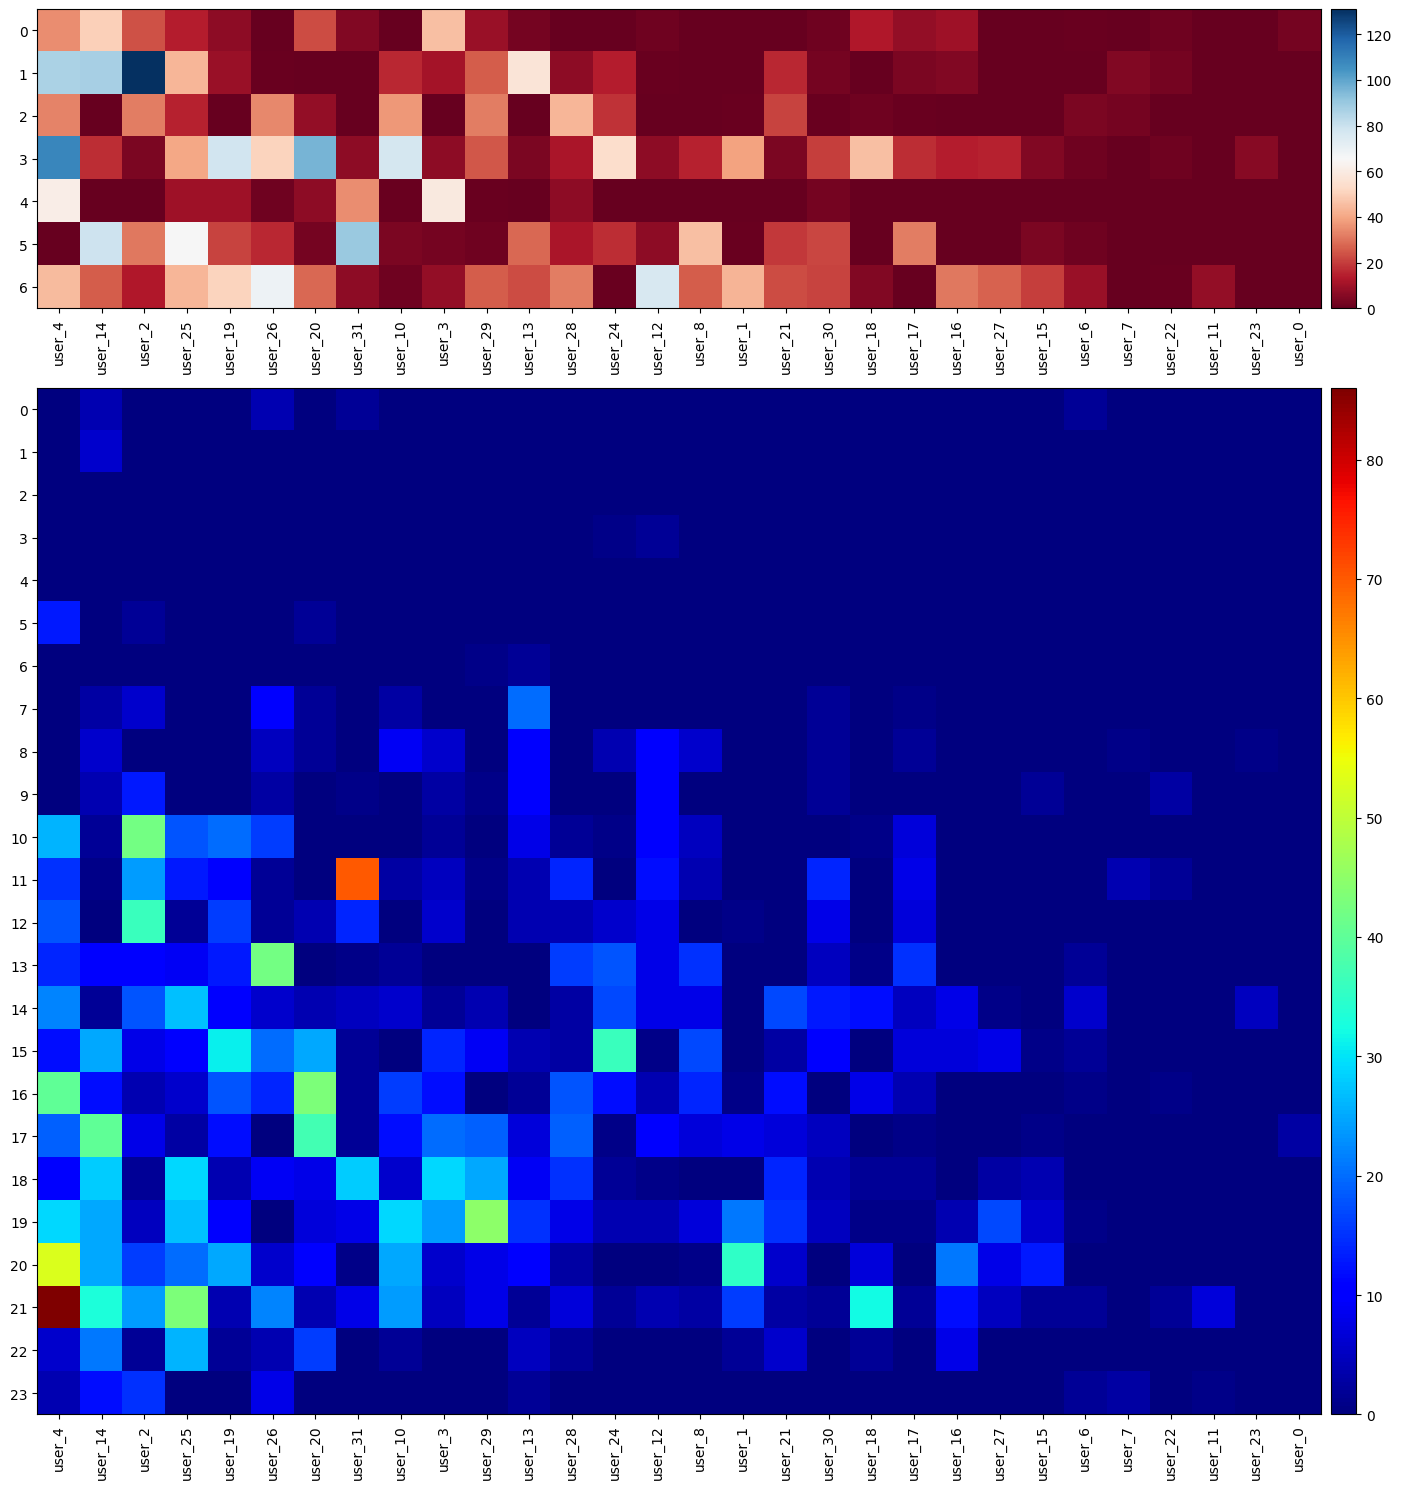

In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

# ---- СОРТИРОВКА ПОЛЬЗОВАТЕЛЕЙ ----
total_commits = stats_commit_day_full.groupby(level='uid').sum()
sorted_users = total_commits.sort_values(ascending=False).index

# ---- HEATMAP ПО ДНЯМ ----
day_of_week_heatmap = (
    stats_commit_day_full
    .groupby(['day','uid'])
    .sum()
    .unstack(fill_value=0)
)

day_of_week_heatmap = day_of_week_heatmap.reindex(index=range(7), fill_value=0)
day_of_week_heatmap = day_of_week_heatmap[sorted_users]

# ---- HEATMAP ПО ЧАСАМ ----
hour_heatmap = (
    stats_commit_day_full
    .groupby(['hour','uid'])
    .sum()
    .unstack(fill_value=0)
)

hour_heatmap = hour_heatmap.reindex(index=range(24), fill_value=0)
hour_heatmap = hour_heatmap[sorted_users]

# ---- ГРАФИКИ (ТВОЙ КОД) ----
fig, (week_day_ax, hour_ax) = plt.subplots(
    2, 1,
    figsize=(15, 15),
    gridspec_kw={'height_ratios': [7, 24]}
)

week_day_im = week_day_ax.imshow(day_of_week_heatmap, cmap='RdBu', aspect='equal')

week_day_ax.set_xticks(range(len(day_of_week_heatmap.columns)))
week_day_ax.set_xticklabels(day_of_week_heatmap.columns, rotation=90)

week_day_ax.set_yticks(range(len(day_of_week_heatmap.index)))
week_day_ax.set_yticklabels(day_of_week_heatmap.index)

divider1 = make_axes_locatable(week_day_ax)
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
plt.colorbar(week_day_im, cax=cax1)

# --- ЧАСЫ ---
hour_im = hour_ax.imshow(hour_heatmap, cmap='jet', aspect='equal')

hour_ax.set_xticks(range(len(hour_heatmap.columns)))
hour_ax.set_xticklabels(hour_heatmap.columns, rotation=90)

hour_ax.set_yticks(range(24))
hour_ax.set_yticklabels([str(x) for x in range(24)])

divider2 = make_axes_locatable(hour_ax)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
plt.colorbar(hour_im, cax=cax2)

plt.tight_layout()
plt.show()

<h2>Answers:</h2>
<h2>User_2</h2>
<h2>User_4</h2>
<h2>Friday</h2>
<h2>User_4, 21</h2>

In [33]:
conn.close()